# Classic Multi-Label Classifiers POC (HealthPH-style)

This notebook uses the same **traditional multi-label classifier family** used in the old HealthPH project:
- Binary Relevance + Logistic Regression
- Binary Relevance + SGD (log_loss)
- Classifier Chains + Logistic Regression
- Classifier Chains + SGD (log_loss)

Target labels (fixed order): `AURI, PN, TB, COVID`.


In [3]:
# Imports
import ast
import importlib.util
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import hstack

# Ensure plotting libs are available inside notebook runtime
if importlib.util.find_spec('matplotlib') is None or importlib.util.find_spec('seaborn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'seaborn'])

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, multilabel_confusion_matrix, precision_recall_fscore_support
from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier

# Ensure optuna is available inside notebook runtime
if importlib.util.find_spec('optuna') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])

import optuna
from optuna.samplers import TPESampler

sns.set_theme(style='whitegrid')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [optuna]2m7/8 [optuna]emy]


/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Config
SEED = 42
TEST_SIZE = 0.10
VAL_SIZE = 0.10
LABELS = ["AURI", "PN", "TB", "COVID"]
DEFAULT_TEXT_COLUMNS = ['post', 'cleaned_text', 'text']
DEFAULT_LABEL_COLUMNS = ['annotate', 'disease', 'annotations']
DEFAULT_LABEL_PARSER_BY_COLUMN = {
    'annotate': 'vector',
    'disease': 'vector',
    'annotations': 'annotation_json_disease',
}

# Optuna tuning config
N_TRIALS = 20
OPTUNA_TIMEOUT_SECONDS = None  # e.g. 1800 for 30 min cap

CWD = Path.cwd()
ROOT_DIR = next((p for p in [CWD, *CWD.parents] if (p / '.git').exists()), CWD)

DATASET_SPECS = [
    {
        'name': 'training_1',
        'path': (ROOT_DIR / 'data' / 'training_data' / 'training_1.csv').resolve(),
        'text_col': 'post',
        'label_col': 'annotate',
        'label_parser': 'auto',
    },
    # {
    #     'name': 'merged_data_annotated',
    #     'path': (ROOT_DIR / 'data' / 'training_data' / 'merged_data_annotated.csv').resolve(),
    #     'text_col': 'cleaned_text',
    #     'label_col': 'annotations',
    #     'label_parser': 'auto',
    # },
]

missing_paths = [spec['path'] for spec in DATASET_SPECS if not spec['path'].exists()]
if missing_paths:
    raise FileNotFoundError(
        'Could not locate training dataset(s) from cwd=' + str(CWD) + ': '
        + ', '.join(str(path) for path in missing_paths)
    )

OUTPUT_DIR = ROOT_DIR / 'reports' / 'classic_multilabel'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    'cwd': str(CWD),
    'root_dir': str(ROOT_DIR),
    'datasets': {spec['name']: str(spec['path']) for spec in DATASET_SPECS},
    'OUTPUT_DIR': str(OUTPUT_DIR),
    'N_TRIALS': N_TRIALS,
    'OPTUNA_TIMEOUT_SECONDS': OPTUNA_TIMEOUT_SECONDS,
})


{'cwd': '/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/notebooks', 'root_dir': '/Users/gelo-p1/Documents/GitHub/HealthPH-Plus', 'datasets': {'training_1': '/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/data/training_data/training_1.csv'}, 'OUTPUT_DIR': '/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/reports/classic_multilabel', 'N_TRIALS': 20, 'OPTUNA_TIMEOUT_SECONDS': None}


In [5]:
# Data loading + validation
def parse_label_vector(value, expected_len=4):
    parsed = ast.literal_eval(str(value))
    if not isinstance(parsed, (list, tuple)):
        raise ValueError('label value must parse to list/tuple')
    if len(parsed) != expected_len:
        raise ValueError(f'label vector length must be {expected_len}')

    out = []
    for item in parsed:
        if item not in (0, 1):
            raise ValueError('label vector values must be 0/1')
        out.append(int(item))
    return out


def parse_annotation_json_disease(value, expected_len=4):
    parsed = json.loads(str(value))
    if not isinstance(parsed, dict):
        raise ValueError('annotations must parse to a JSON object')
    if 'disease' not in parsed:
        raise ValueError('annotations JSON must include disease')

    disease = parsed['disease']
    if not isinstance(disease, list):
        raise ValueError('annotations["disease"] must be a list')
    if len(disease) != expected_len:
        raise ValueError(f'annotations["disease"] length must be {expected_len}')

    out = []
    for item in disease:
        if item not in (0, 1):
            raise ValueError('annotations["disease"] values must be 0/1')
        out.append(int(item))
    return out


def parse_labels(value, parser_name, expected_len=4):
    if parser_name == 'vector':
        return parse_label_vector(value, expected_len=expected_len)
    if parser_name == 'annotation_json_disease':
        return parse_annotation_json_disease(value, expected_len=expected_len)
    raise ValueError(f'Unknown label parser: {parser_name}')


def column_candidates(spec, key, defaults):
    values = []
    for value in [spec.get(key), *spec.get(f'{key}_candidates', []), *defaults]:
        if value and value not in values:
            values.append(value)
    return values


def resolve_column(spec, columns, key, defaults, role):
    candidates = column_candidates(spec, key, defaults)
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise ValueError(
        f"{spec['name']} is missing a {role} column. "
        f"Tried {candidates}. Available columns: {columns}"
    )


def resolve_label_parser(spec, label_col):
    parser_name = spec.get('label_parser', 'auto')
    configured_label_col = spec.get('label_col')
    if parser_name == 'auto' or label_col != configured_label_col:
        if label_col not in DEFAULT_LABEL_PARSER_BY_COLUMN:
            raise ValueError(f"No default label parser configured for column: {label_col}")
        return DEFAULT_LABEL_PARSER_BY_COLUMN[label_col]
    return parser_name


rows = []
source_stats = []

for spec in DATASET_SPECS:
    available_columns = pd.read_csv(spec['path'], nrows=0).columns.tolist()
    text_col = resolve_column(spec, available_columns, 'text_col', DEFAULT_TEXT_COLUMNS, 'text')
    label_col = resolve_column(spec, available_columns, 'label_col', DEFAULT_LABEL_COLUMNS, 'label')
    label_parser = resolve_label_parser(spec, label_col)
    raw_df = pd.read_csv(spec['path'], usecols=[text_col, label_col])
    stats = {
        'source': spec['name'],
        'path': str(spec['path']),
        'raw_rows': len(raw_df),
        'text_col': text_col,
        'label_col': label_col,
        'label_parser': label_parser,
        'blank_text_rows': 0,
        'invalid_label_rows': 0,
        'valid_rows': 0,
    }

    for _, row in raw_df.iterrows():
        text = row.get(text_col)
        label_value = row.get(label_col)

        if not isinstance(text, str) or not text.strip():
            stats['blank_text_rows'] += 1
            continue

        try:
            y = parse_labels(label_value, label_parser, expected_len=len(LABELS))
        except Exception:
            stats['invalid_label_rows'] += 1
            continue

        rows.append({
            'text': ' '.join(text.split()),
            'annotate': str(y),
            'source': spec['name'],
        })
        stats['valid_rows'] += 1

    source_stats.append(stats)

all_rows_df = pd.DataFrame(rows)
clean_df = all_rows_df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
y_all = np.asarray(clean_df['annotate'].apply(ast.literal_eval).tolist(), dtype=int)

print('source_stats=')
for stats in source_stats:
    print(stats)
print('valid_rows_total=', len(all_rows_df), 'clean_rows=', len(clean_df), 'duplicate_rows_dropped=', len(all_rows_df) - len(clean_df))
print('label_counts=', dict(zip(LABELS, y_all.sum(axis=0).tolist())))


source_stats=
{'source': 'training_1', 'path': '/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/data/training_data/training_1.csv', 'raw_rows': 21968, 'text_col': 'post', 'label_col': 'annotate', 'label_parser': 'vector', 'blank_text_rows': 0, 'invalid_label_rows': 0, 'valid_rows': 21968}
valid_rows_total= 21968 clean_rows= 6290 duplicate_rows_dropped= 15678
label_counts= {'AURI': 1272, 'PN': 859, 'TB': 953, 'COVID': 1285}


In [6]:
# Iterative multilabel split (dependency-free)
def iterative_multilabel_split_indices(y, test_size=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y, dtype=int)

    n_samples, n_labels = y.shape
    n_test = int(round(n_samples * test_size))
    n_test = max(1, min(n_samples - 1, n_test))

    all_idx = np.arange(n_samples)
    unassigned = set(all_idx.tolist())
    test_idx = []

    target = y.sum(axis=0) * test_size
    current = np.zeros(n_labels, dtype=float)
    cardinality = y.sum(axis=1)

    while len(test_idx) < n_test and unassigned:
        deficits = np.where(target - current > 0, target - current, 0)

        if deficits.sum() == 0:
            rem = np.array(list(unassigned))
            rng.shuffle(rem)
            test_idx.extend(rem[: (n_test - len(test_idx))].tolist())
            break

        chosen = None
        for label in np.argsort(-deficits):
            candidates = [i for i in unassigned if y[i, label] == 1]
            if not candidates:
                continue
            min_card = min(cardinality[candidates])
            filtered = [i for i in candidates if cardinality[i] == min_card]
            chosen = int(rng.choice(filtered))
            break

        if chosen is None:
            chosen = int(rng.choice(np.array(list(unassigned))))

        test_idx.append(chosen)
        unassigned.remove(chosen)
        current += y[chosen]

    test_idx = np.array(sorted(set(test_idx)))
    train_idx = np.array(sorted(list(set(all_idx) - set(test_idx))))
    return train_idx, test_idx


trainval_idx, test_idx = iterative_multilabel_split_indices(y_all, test_size=TEST_SIZE, random_state=SEED)
trainval_df = clean_df.iloc[trainval_idx].reset_index(drop=True)
test_df = clean_df.iloc[test_idx].reset_index(drop=True)
y_trainval = y_all[trainval_idx]
y_test = y_all[test_idx]

val_rel = VAL_SIZE / (1.0 - TEST_SIZE)
train_idx_local, val_idx_local = iterative_multilabel_split_indices(
    y_trainval,
    test_size=val_rel,
    random_state=SEED,
)

train_df = trainval_df.iloc[train_idx_local].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx_local].reset_index(drop=True)
y_train = y_trainval[train_idx_local]
y_val = y_trainval[val_idx_local]

print('train=', len(train_df), 'val=', len(val_df), 'test=', len(test_df))


train= 5032 val= 629 test= 629


In [7]:
# TF-IDF feature pipeline
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, max_features=100_000)
char_vec = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=2, max_features=100_000)

X_train = hstack([word_vec.fit_transform(train_df['text']), char_vec.fit_transform(train_df['text'])])
X_val = hstack([word_vec.transform(val_df['text']), char_vec.transform(val_df['text'])])
X_test = hstack([word_vec.transform(test_df['text']), char_vec.transform(test_df['text'])])

print('X_train_shape=', X_train.shape)


X_train_shape= (5032, 134658)


In [8]:
# Helpers: probability extraction, threshold tuning, evaluation
def predict_proba_matrix(model, X):
    raw = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

    if isinstance(raw, list):
        cols = []
        for arr in raw:
            arr = np.asarray(arr)
            if arr.ndim == 1:
                cols.append(arr)
            elif arr.ndim == 2 and arr.shape[1] >= 2:
                cols.append(arr[:, 1])
            elif arr.ndim == 2 and arr.shape[1] == 1:
                cols.append(arr[:, 0])
            else:
                raise ValueError(f'Unsupported per-label proba shape: {arr.shape}')
        return np.column_stack(cols)

    if raw is not None:
        raw = np.asarray(raw)
        if raw.ndim == 2:
            return raw
        if raw.ndim == 3 and raw.shape[2] >= 2:
            return raw[:, :, 1]

    if hasattr(model, 'decision_function'):
        d = np.asarray(model.decision_function(X))
        return 1 / (1 + np.exp(-d))

    raise RuntimeError('Model has no predict_proba/decision_function')


def tune_thresholds(y_true, y_proba, labels):
    thresholds = {}
    grid = np.arange(0.10, 0.901, 0.01)

    for i, label in enumerate(labels):
        best_t = 0.5
        best_f1 = -1.0
        for t in grid:
            pred = (y_proba[:, i] >= t).astype(int)
            _, _, f1, _ = precision_recall_fscore_support(
                y_true[:, i], pred, average='binary', zero_division=0
            )
            if f1 > best_f1:
                best_f1 = float(f1)
                best_t = float(np.round(t, 4))
        thresholds[label] = best_t

    return thresholds


def apply_thresholds(y_proba, thresholds, labels):
    y_pred = np.zeros_like(y_proba, dtype=int)
    for i, label in enumerate(labels):
        y_pred[:, i] = (y_proba[:, i] >= thresholds[label]).astype(int)
    return y_pred


def evaluate(y_true, y_pred, labels):
    summary = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'micro_f1': float(f1_score(y_true, y_pred, average='micro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'hamming_loss': float(hamming_loss(y_true, y_pred)),
        'exact_match_ratio': float(np.mean(np.all(y_true == y_pred, axis=1))),
    }

    per_label_rows = []
    for i, label in enumerate(labels):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, i], y_pred[:, i], average='binary', zero_division=0
        )
        per_label_rows.append({'label': label, 'precision': float(p), 'recall': float(r), 'f1': float(f1)})

    mcm = multilabel_confusion_matrix(y_true, y_pred)
    cm_rows = []
    for i, label in enumerate(labels):
        tn, fp, fn, tp = mcm[i].ravel()
        cm_rows.append({'label': label, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    return summary, pd.DataFrame(per_label_rows), pd.DataFrame(cm_rows)


In [9]:
# Model definitions + builders (HealthPH classic approach)
MODEL_FAMILIES = [
    'BinaryRelevance_LogReg',
    'BinaryRelevance_SGD',
    'ClassifierChains_LogReg',
    'ClassifierChains_SGD',
]


def build_model(model_name, params, seed=SEED):
    if model_name == 'BinaryRelevance_LogReg':
        base = LogisticRegression(
            class_weight='balanced',
            solver='saga',
            C=float(params['C']),
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return OneVsRestClassifier(base)

    if model_name == 'BinaryRelevance_SGD':
        base = SGDClassifier(
            loss='log_loss',
            alpha=float(params['alpha']),
            penalty=str(params['penalty']),
            class_weight='balanced',
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return OneVsRestClassifier(base)

    if model_name == 'ClassifierChains_LogReg':
        base = LogisticRegression(
            class_weight='balanced',
            solver='saga',
            C=float(params['C']),
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return ClassifierChain(base, order='random', random_state=seed)

    if model_name == 'ClassifierChains_SGD':
        base = SGDClassifier(
            loss='log_loss',
            alpha=float(params['alpha']),
            penalty=str(params['penalty']),
            class_weight='balanced',
            max_iter=int(params['max_iter']),
            random_state=seed,
        )
        return ClassifierChain(base, order='random', random_state=seed)

    raise ValueError(f'Unknown model_name: {model_name}')


def suggest_params(trial, model_name):
    if 'LogReg' in model_name:
        return {
            'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
            'max_iter': trial.suggest_int('max_iter', 800, 2500, step=100),
        }

    # SGD search space
    return {
        'alpha': trial.suggest_float('alpha', 1e-6, 1e-2, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'max_iter': trial.suggest_int('max_iter', 1000, 3000, step=250),
    }


MODEL_FAMILIES


['BinaryRelevance_LogReg',
 'BinaryRelevance_SGD',
 'ClassifierChains_LogReg',
 'ClassifierChains_SGD']

In [10]:
# Optuna tuning + train + summary-only outputs
summary_rows = []
best_params_by_model = {}


for model_name in MODEL_FAMILIES:
    print(f'\n===== {model_name} =====')

    def objective(trial):
        params = suggest_params(trial, model_name)
        model = build_model(model_name, params, seed=SEED)
        model.fit(X_train, y_train)

        val_proba = predict_proba_matrix(model, X_val)
        thresholds = tune_thresholds(y_val, val_proba, LABELS)
        y_val_pred = apply_thresholds(val_proba, thresholds, LABELS)

        # Optimize for validation micro-F1
        score = f1_score(y_val, y_val_pred, average='micro', zero_division=0)
        return float(score)

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED),
        study_name=model_name,
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT_SECONDS)

    best_params = study.best_params
    best_val_score = float(study.best_value)
    print('Best val micro_f1:', round(best_val_score, 4))
    print('Best params:', best_params)

    # Train final model with best params
    model = build_model(model_name, best_params, seed=SEED)
    model.fit(X_train, y_train)

    # Validation metrics
    val_proba = predict_proba_matrix(model, X_val)
    thresholds = tune_thresholds(y_val, val_proba, LABELS)
    y_val_pred = apply_thresholds(val_proba, thresholds, LABELS)
    val_summary, _, _ = evaluate(y_val, y_val_pred, LABELS)

    # Test metrics
    test_proba = predict_proba_matrix(model, X_test)
    y_test_pred = apply_thresholds(test_proba, thresholds, LABELS)
    test_summary, _, _ = evaluate(y_test, y_test_pred, LABELS)

    best_params_by_model[model_name] = {
        'best_params': best_params,
        'thresholds': thresholds,
        'best_val_micro_f1': best_val_score,
        'n_trials': len(study.trials),
    }

    summary_rows.append({
        'model': model_name,
        'optuna_best_val_micro_f1': best_val_score,
        'val_accuracy': val_summary['accuracy'],
        'val_micro_f1': val_summary['micro_f1'],
        'val_macro_f1': val_summary['macro_f1'],
        'val_hamming_loss': val_summary['hamming_loss'],
        'val_exact_match_ratio': val_summary['exact_match_ratio'],
        'test_accuracy': test_summary['accuracy'],
        'test_micro_f1': test_summary['micro_f1'],
        'test_macro_f1': test_summary['macro_f1'],
        'test_hamming_loss': test_summary['hamming_loss'],
        'test_exact_match_ratio': test_summary['exact_match_ratio'],
        'n_trials': len(study.trials),
        'best_params': json.dumps(best_params, sort_keys=True),
        'thresholds': json.dumps(thresholds, sort_keys=True),
    })

    print(
        model_name,
        'test_accuracy=', round(test_summary['accuracy'], 4),
        'test_micro_f1=', round(test_summary['micro_f1'], 4),
        'test_macro_f1=', round(test_summary['macro_f1'], 4),
    )


[I 2026-07-29 11:01:32,179] A new study created in memory with name: BinaryRelevance_LogReg



===== BinaryRelevance_LogReg =====


[I 2026-07-29 11:01:33,270] Trial 0 finished with value: 0.6732533521524348 and parameters: {'C': 0.03148911647956861, 'max_iter': 2500}. Best is trial 0 with value: 0.6732533521524348.
/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-07-29 11:01:57,060] Trial 1 finished with value: 0.7233748271092669 and parameters: {'C': 0.847180141881998, 'max_iter': 1800}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-07-29 11:01:58,091] Trial 2 finished with value: 0.6429070580013976 and parameters: {'C': 0.004207988669606638, 'max_iter': 1000}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-07-29 11:01:59,134] Trial 3 finished with value: 0.6354515050167224 and parameters: {'C': 0.0017073967431528124, 'max_iter': 2300}. Best is trial 1 with value: 0.7233748271092669.
[I 2026-07-29 11:02:00,809] Trial 4 fin

Best val micro_f1: 0.7243
Best params: {'C': 1.8013302744925745, 'max_iter': 2100}


/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-07-29 11:05:42,176] A new study created in memory with name: BinaryRelevance_SGD


...

Best val micro_f1: 0.7144
Best params: {'C': 0.8867236671480978, 'max_iter': 2200}


/Users/gelo-p1/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-07-29 11:10:15,849] A new study created in memory with name: ClassifierChains_SGD


ClassifierChains_LogReg test_accuracy= 0.4165 test_micro_f1= 0.5162 test_macro_f1= 0.5105

===== ClassifierChains_SGD =====


[I 2026-07-29 11:10:16,350] Trial 0 finished with value: 0.6865671641791045 and parameters: {'alpha': 3.1489116479568635e-05, 'penalty': 'l2', 'max_iter': 1250}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-07-29 11:10:17,367] Trial 1 finished with value: 0.6431718061674009 and parameters: {'alpha': 4.207053950287936e-06, 'penalty': 'l1', 'max_iter': 2500}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-07-29 11:10:18,050] Trial 2 finished with value: 0.6376360808709176 and parameters: {'alpha': 1.2087541473056965e-06, 'penalty': 'l2', 'max_iter': 1250}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-07-29 11:10:19,027] Trial 3 finished with value: 0.6426470588235295 and parameters: {'alpha': 5.415244119402541e-06, 'penalty': 'l1', 'max_iter': 1500}. Best is trial 0 with value: 0.6865671641791045.
[I 2026-07-29 11:10:19,839] Trial 4 finished with value: 0.7133243606998654 and parameters: {'alpha': 0.0002801635158716259, 'penalty': 'elasticnet', 'max_iter': 

Best val micro_f1: 0.7143
Best params: {'alpha': 0.00012452668108659282, 'penalty': 'elasticnet', 'max_iter': 2250}
ClassifierChains_SGD test_accuracy= 0.4149 test_micro_f1= 0.5389 test_macro_f1= 0.5313


In [11]:
# Final summary log
summary_df = pd.DataFrame(summary_rows).sort_values(by='test_micro_f1', ascending=False).reset_index(drop=True)
summary_path = OUTPUT_DIR / 'multilabel_evaluation_summary.csv'
summary_df.to_csv(summary_path, index=False)

print('Saved summary log to', summary_path)

summary_df


Saved summary log to /Users/gelo-p1/Documents/GitHub/HealthPH-Plus/reports/classic_multilabel/multilabel_evaluation_summary.csv


,model,optuna_best_val_micro_f1,val_accuracy,val_micro_f1,val_macro_f1,val_hamming_loss,val_exact_match_ratio,test_accuracy,test_micro_f1,test_macro_f1,test_hamming_loss,test_exact_match_ratio,n_trials,best_params,thresholds
0,ClassifierChains_SGD,0.714286,0.661367,0.714286,0.709752,0.163752,0.661367,0.414944,0.538874,0.531302,0.273450,0.414944,20,"{""alpha"": 0.00012452668108659282, ""max_iter"": ...","{""AURI"": 0.1, ""COVID"": 0.18, ""PN"": 0.45, ""TB"":..."
1,BinaryRelevance_LogReg,0.724252,0.662957,0.724252,0.715989,0.164944,0.662957,0.376789,0.529680,0.517545,0.286566,0.376789,20,"{""C"": 1.8013302744925745, ""max_iter"": 2100}","{""AURI"": 0.32, ""COVID"": 0.36, ""PN"": 0.39, ""TB""..."
2,BinaryRelevance_SGD,0.725762,0.682035,0.725762,0.719974,0.157393,0.682035,0.386328,0.525667,0.516906,0.275437,0.386328,20,"{""alpha"": 0.00012452668108659282, ""max_iter"": ...","{""AURI"": 0.48, ""COVID"": 0.47, ""PN"": 0.45, ""TB""..."
3,ClassifierChains_LogReg,0.714386,0.670906,0.714386,0.709951,0.161765,0.670906,0.416534,0.516174,0.510451,0.273450,0.416534,20,"{""C"": 0.8867236671480978, ""max_iter"": 2200}","{""AURI"": 0.1, ""COVID"": 0.21, ""PN"": 0.48, ""TB"":..."


## Results Analysis (Dynamic Graphs and Matrices)

This section is computed from files in `reports/classic_multilabel` each time you run it.
No metric values are hard-coded in markdown.

In [12]:
# Load summary log only
analysis_dir = OUTPUT_DIR
summary_path = analysis_dir / 'multilabel_evaluation_summary.csv'

if not summary_path.exists():
    raise FileNotFoundError(
        f'{summary_path} not found. Run the model training/evaluation cells first.'
    )

summary_vis = pd.read_csv(summary_path).sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
summary_vis['generalization_gap_micro_f1'] = summary_vis['val_micro_f1'] - summary_vis['test_micro_f1']
if {'val_accuracy', 'test_accuracy'}.issubset(summary_vis.columns):
    summary_vis['generalization_gap_accuracy'] = summary_vis['val_accuracy'] - summary_vis['test_accuracy']

per_label_df = pd.DataFrame()
confusion_df = pd.DataFrame()
trials_df = pd.DataFrame()
threshold_rows = []

if 'thresholds' in summary_vis.columns:
    for _, row in summary_vis.iterrows():
        raw_thresholds = row.get('thresholds')
        if pd.isna(raw_thresholds):
            continue
        try:
            thresholds = json.loads(raw_thresholds)
        except (TypeError, json.JSONDecodeError):
            continue
        for label, value in thresholds.items():
            threshold_rows.append({'model': row['model'], 'label': label, 'threshold': float(value)})

threshold_df = pd.DataFrame(threshold_rows)

print('Loaded summary log from:', summary_path)
print('Summary rows:', len(summary_vis))
print('Threshold rows:', len(threshold_df))
print('Detailed per-label, confusion, Optuna-trial, and prediction artifacts are not loaded because only the summary log is saved.')

summary_vis


Loaded summary log from: /Users/gelo-p1/Documents/GitHub/HealthPH-Plus/reports/classic_multilabel/multilabel_evaluation_summary.csv
Summary rows: 4
Threshold rows: 16
Detailed per-label, confusion, Optuna-trial, and prediction artifacts are not loaded because only the summary log is saved.


,model,optuna_best_val_micro_f1,val_accuracy,val_micro_f1,val_macro_f1,val_hamming_loss,val_exact_match_ratio,test_accuracy,test_micro_f1,test_macro_f1,test_hamming_loss,test_exact_match_ratio,n_trials,best_params,thresholds,generalization_gap_micro_f1,generalization_gap_accuracy
0,ClassifierChains_SGD,0.714286,0.661367,0.714286,0.709752,0.163752,0.661367,0.414944,0.538874,0.531302,0.273450,0.414944,20,"{""alpha"": 0.00012452668108659282, ""max_iter"": ...","{""AURI"": 0.1, ""COVID"": 0.18, ""PN"": 0.45, ""TB"":...",0.175412,0.246423
1,BinaryRelevance_LogReg,0.724252,0.662957,0.724252,0.715989,0.164944,0.662957,0.376789,0.529680,0.517545,0.286566,0.376789,20,"{""C"": 1.8013302744925745, ""max_iter"": 2100}","{""AURI"": 0.32, ""COVID"": 0.36, ""PN"": 0.39, ""TB""...",0.194572,0.286169
2,BinaryRelevance_SGD,0.725762,0.682035,0.725762,0.719974,0.157393,0.682035,0.386328,0.525667,0.516906,0.275437,0.386328,20,"{""alpha"": 0.00012452668108659282, ""max_iter"": ...","{""AURI"": 0.48, ""COVID"": 0.47, ""PN"": 0.45, ""TB""...",0.200094,0.295707
3,ClassifierChains_LogReg,0.714386,0.670906,0.714386,0.709951,0.161765,0.670906,0.416534,0.516174,0.510451,0.273450,0.416534,20,"{""C"": 0.8867236671480978, ""max_iter"": 2200}","{""AURI"": 0.1, ""COVID"": 0.21, ""PN"": 0.48, ""TB"":...",0.198212,0.254372


/var/folders/_y/887f14s91r70g80xdgn0yc8h0000gn/T/ipykernel_18852/1544922790.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


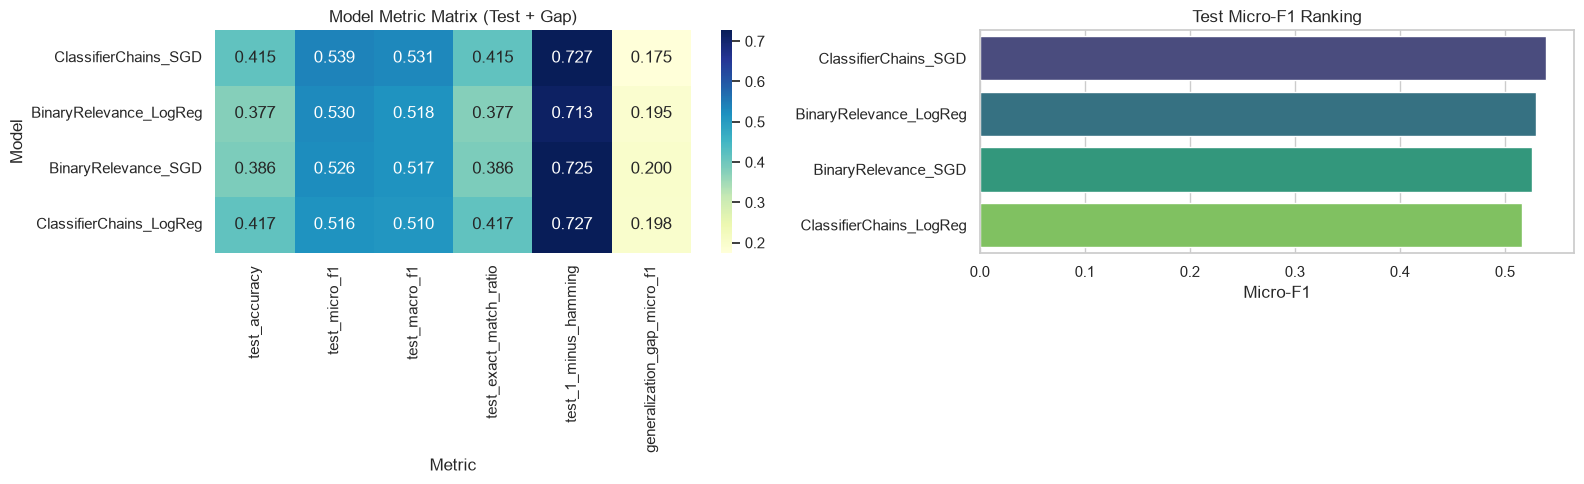

/var/folders/_y/887f14s91r70g80xdgn0yc8h0000gn/T/ipykernel_18852/1544922790.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


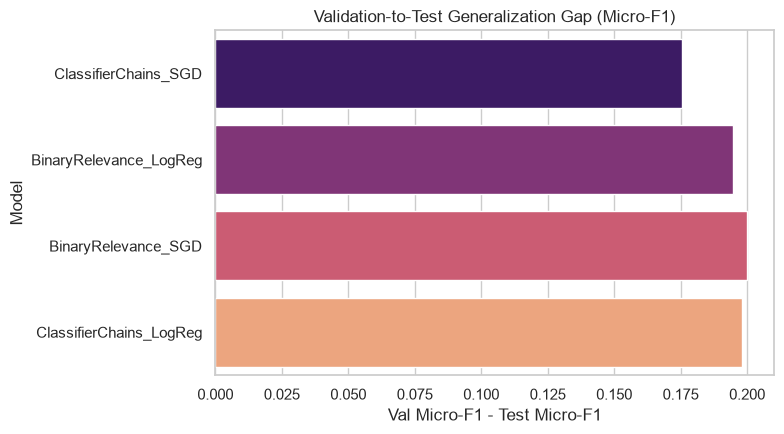

In [13]:
# Overall performance graphs/matrices
plot_df = summary_vis.copy()
plot_df['test_1_minus_hamming'] = 1.0 - plot_df['test_hamming_loss']

metric_cols = [
    'test_accuracy',
    'test_micro_f1',
    'test_macro_f1',
    'test_exact_match_ratio',
    'test_1_minus_hamming',
    'generalization_gap_micro_f1',
]
metric_cols = [col for col in metric_cols if col in plot_df.columns]

metric_matrix = plot_df.set_index('model')[metric_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    metric_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    ax=axes[0],
)
axes[0].set_title('Model Metric Matrix (Test + Gap)')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Model')

sns.barplot(
    data=plot_df,
    y='model',
    x='test_micro_f1',
    orient='h',
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title('Test Micro-F1 Ranking')
axes[1].set_xlabel('Micro-F1')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=plot_df,
    y='model',
    x='generalization_gap_micro_f1',
    orient='h',
    palette='magma',
    ax=ax,
)
ax.set_title('Validation-to-Test Generalization Gap (Micro-F1)')
ax.set_xlabel('Val Micro-F1 - Test Micro-F1')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()


In [14]:
# Per-label performance matrices/graphs
print('Per-label plots are unavailable because this notebook now saves only the summary log.')


Per-label plots are unavailable because this notebook now saves only the summary log.


In [15]:
# Confusion-derived matrices + binary confusion matrices for best model
print('Confusion-derived plots are unavailable because this notebook now saves only the summary log.')


Confusion-derived plots are unavailable because this notebook now saves only the summary log.


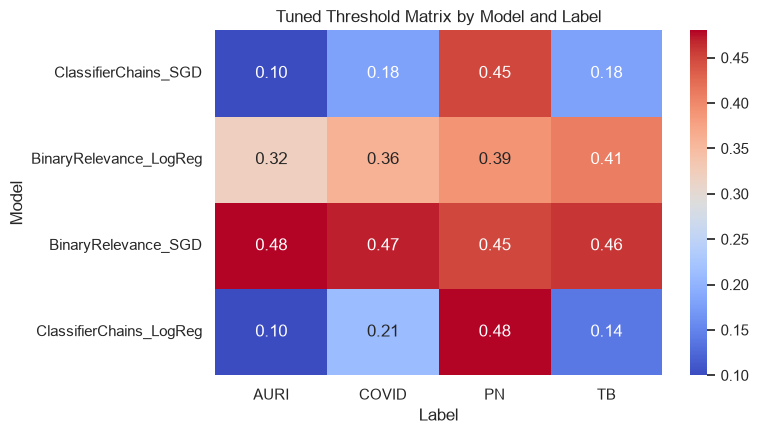

Optuna search curves are unavailable because trial-level logs are no longer saved.


In [16]:
# Threshold matrix + Optuna search curves
if not threshold_df.empty:
    threshold_matrix = threshold_df.pivot(index='model', columns='label', values='threshold').reindex(index=summary_vis['model'])
    plt.figure(figsize=(8, 4.5))
    sns.heatmap(threshold_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Tuned Threshold Matrix by Model and Label')
    plt.xlabel('Label')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()
else:
    print('No threshold values available in the summary log.')

print('Optuna search curves are unavailable because trial-level logs are no longer saved.')


In [17]:
# True-vs-predicted label-combination matrix (best model)
print('True-vs-predicted label-combination plots are unavailable because test predictions are no longer saved.')


True-vs-predicted label-combination plots are unavailable because test predictions are no longer saved.


## Interactive Prediction Test

Run this cell to input a sentence and classify it with the best-performing model (by test micro-F1).

In [18]:
# Interactive one-sentence prediction using the best model
required_vars = ['X_train', 'y_train', 'X_val', 'y_val', 'word_vec', 'char_vec', 'OUTPUT_DIR']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing required variables: ' + ', '.join(missing)
        + '. Run data prep, vectorization, and training cells first.'
    )

if 'summary_df' in globals() and isinstance(summary_df, pd.DataFrame) and not summary_df.empty:
    ranking_df = summary_df.sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
elif 'summary_vis' in globals() and isinstance(summary_vis, pd.DataFrame) and not summary_vis.empty:
    ranking_df = summary_vis.sort_values('test_micro_f1', ascending=False).reset_index(drop=True)
else:
    summary_path = OUTPUT_DIR / 'multilabel_evaluation_summary.csv'
    if not summary_path.exists():
        raise FileNotFoundError(f'{summary_path} not found. Run training/evaluation first.')
    ranking_df = pd.read_csv(summary_path).sort_values('test_micro_f1', ascending=False).reset_index(drop=True)

best_model_name = ranking_df.iloc[0]['model']
best_row = ranking_df.iloc[0]

if 'best_params_by_model' in globals() and best_model_name in best_params_by_model:
    best_params = best_params_by_model[best_model_name]['best_params']
elif 'best_params' in ranking_df.columns and not pd.isna(best_row.get('best_params')):
    best_params = json.loads(best_row['best_params'])
else:
    raise FileNotFoundError(
        'Best parameters are not available. Run tuning/training first or use a summary log that includes best_params.'
    )

inference_model = build_model(best_model_name, best_params, seed=SEED)
inference_model.fit(X_train, y_train)

if 'best_params_by_model' in globals() and best_model_name in best_params_by_model and 'thresholds' in best_params_by_model[best_model_name]:
    thresholds = best_params_by_model[best_model_name]['thresholds']
elif 'thresholds' in ranking_df.columns and not pd.isna(best_row.get('thresholds')):
    thresholds = {k: float(v) for k, v in json.loads(best_row['thresholds']).items()}
else:
    # Fallback: derive thresholds from the current validation split
    val_proba = predict_proba_matrix(inference_model, X_val)
    thresholds = tune_thresholds(y_val, val_proba, LABELS)

# Edit this before each run
user_text = 'hindi ako makahinga'
user_text = user_text.strip()
if not user_text:
    raise ValueError('`user_text` is empty. Set a non-empty sentence before running this cell.')

X_user = hstack([word_vec.transform([user_text]), char_vec.transform([user_text])])
user_proba = predict_proba_matrix(inference_model, X_user)
user_pred = apply_thresholds(user_proba, thresholds, LABELS)[0]

predicted_labels = [label for i, label in enumerate(LABELS) if int(user_pred[i]) == 1]
print(f'Best model used: {best_model_name}')
print('Predicted labels:', ', '.join(predicted_labels) if predicted_labels else 'NONE')

pd.DataFrame(
    {
        'label': LABELS,
        'probability': user_proba[0],
        'threshold': [thresholds[label] for label in LABELS],
        'predicted': user_pred.astype(int),
    }
).sort_values('probability', ascending=False).reset_index(drop=True)


Best model used: ClassifierChains_SGD
Predicted labels: NONE


,label,probability,threshold,predicted
0,PN,0.320875,0.45,0
1,COVID,0.129372,0.18,0
2,TB,0.035727,0.18,0
3,AURI,0.022289,0.10,0
